In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/utils.py:429: 

In [2]:
allsample_rna_file = '/mnt/hdd_alice/syy/adipose/rna/Analysis/SCVI_integration/adata_integrated_soupXoutput_with_infer.h5ad'
allsample_rna = sc.read(allsample_rna_file)

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
sean_celltype_rna = pd.read_csv('/mnt/hdd_alice/syy/adipose/rna/Analysis/Sean_allsamples_cluster_type_annotation.csv')
sean_celltype_rna['leiden_scVI'] = sean_celltype_rna['leiden_scVI'].astype(str)
sean_celltype_rna.head()

,leiden_scVI,cell_type
0,0,White Adipocytes
1,1,Adipocyte Progenitor Cells
2,2,Macrophages
3,3,Endothelial Cells 1
4,4,Mesothelium


In [ ]:
allsample_rna.obs.reset_index(inplace=True, drop=False)
allsample_rna.obs = allsample_rna.obs.merge(sean_celltype_rna[['leiden_scVI', 'cell_type']], left_on='leiden_scVI', right_on='leiden_scVI', how='left')
allsample_rna.obs.set_index('index', inplace=True, drop=True)

In [16]:
allsample_rna.obs.head()

,sample,_scvi_batch,_scvi_labels,leiden_scVI,_scvi_raw_norm_scaling,cell_type
index,,,,,,
GTGCAGCCATTACTCT-1,AB_AOM,0,0,0,0.188698,White Adipocytes
CCCTTAGTCAGCTCTC-1,AB_AOM,0,0,5,0.208297,Unknown 2
CCTTTGGCACTAGGCC-1,AB_AOM,0,0,0,0.251779,White Adipocytes
TATACCTCACGTCTCT-1,AB_AOM,0,0,0,0.300117,White Adipocytes
TGCGACGCATGACTCA-1,AB_AOM,0,0,4,0.305950,Mesothelium


In [17]:
save_df = allsample_rna.obs[['leiden_scVI', 'cell_type', 'sample']].copy()
save_df.columns = ['leiden_scVI', 'cell_type', 'sample']
save_df.to_csv('/home/syyang/GitRepo/atac/Analysis_adipose/allsamples_rna/allsample_rna_celltype_asign_sean.tsv', index=True, header=True, sep='\t',  na_rep='NA')

# Marker vis by Shiyi

In [3]:
nk_celltype_markers_file = '/mnt/hdd_alice/kevinan/adipose/reference/nk.markers.txt'
nk_celltype_markers = pd.read_csv(nk_celltype_markers_file, sep='\t', header=None)

ab_celltype_markers_file = '/mnt/hdd_alice/kevinan/adipose/reference/ab.markers.txt'
ab_celltype_markers = pd.read_csv(ab_celltype_markers_file, sep='\t', header=None)

In [4]:
nk_celltype_markers

,0,1
0,BrownAd,"COBL,TBATA,PPARGC1A,PLIN5,PDE3B,ADIPOQ"
1,Endo,"VEGFC,ADGRF5,VWF"
2,FAP1,"NEGR1,ABCA10"
3,FAP2,"FBN1,MEG8"
4,PRM1,"PRM1,TNP1,TUBA3C,REXO4,ODF2"
5,LympEndo,"PKHD1L1,NRG3,MMRN1"
6,Macroph,"F13A1,CD163"
7,Mast,"HPGD,RAB27B,IL18R1"
8,SMC,"MYH11,ACTA2"
9,Neur1,CNTNAP2


In [5]:
ab_celltype_markers

,0,1
0,APC III,"PDGFRA,CD34,EPHA3,COL1A2,PAK3,KCNIP1,LAMA2,FBL..."
1,APCII,"PDGFRA,CD34,FGF10,ADAMTSL3,NOVA1,LAMA2,ABCA9,N..."
2,Adipogenic Progenitor Cells (APC) I,"PDGFRA,CD34,MFAP5,ADAMTSL1,MFAP5,CREB5,ADAMTS1..."
3,B Cells,"PTPRC,BCL11A,MS4A1,BLK,RALGPS2,FCRL1,PAX5,BANK1"
4,CNTNAP+,"CNTNAP2,GRID2,CNTN5,CSMD3,NRG1,NRXN1,NRXN3,SAA1"
5,Endothelial ACs,"PECAM1,JAM2,VEGFC,LINC01695,PCSK5,NKAIN2,MECOM..."
6,Endothelial VCs,"PECAM1,MECOM,JAM2,PRAG1,KALRN,ANO2,ADGRL4,ABLI..."
7,Endothelial SCs,"PECAM1,MECOM,JAM2,LHX6,TPO,PLCB4,RAB3C,RYR3,NA..."
8,Erythroblasts,"KRT1,RPS12,HBM,ALAS2,HBA1,HBA2,HBB"
9,Fibroblasts,"SPTBN1,LINC00342,SETX,PPP1R12A,NIPBL,ZC3H13,MA..."


In [6]:
allsample_rna

AnnData object with n_obs × n_vars = 179542 × 34812
    obs: 'sample', '_scvi_batch', '_scvi_labels', 'leiden_scVI', '_scvi_raw_norm_scaling'
    var: 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'hvg', 'leiden_scVI', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log_10k_norm'
    obsp: 'connectivities', 'distances'

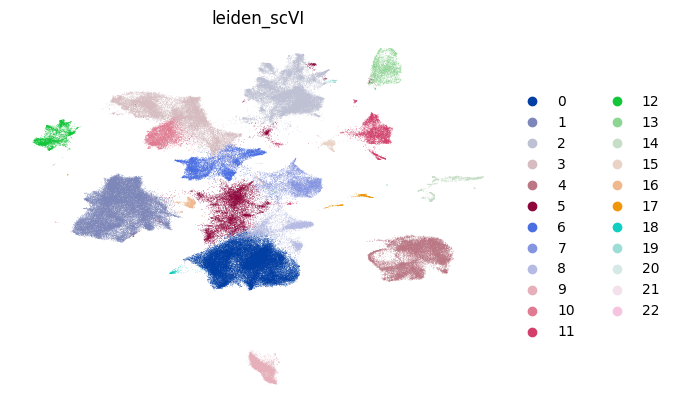

In [7]:
sc.pl.umap(allsample_rna, color=['leiden_scVI'], frameon=False)

In [8]:
celltype_markers = ["ADIPOQ", "AQP7", "LPL", "PLIN1", "PDGFRA", "MS4A1", "CLEC9A", "VWF", "FLT4", "CD163", "KIT", "MSLN", "ITGAM", "TAGLN", "DPP4", "PROS1", "CD247"]


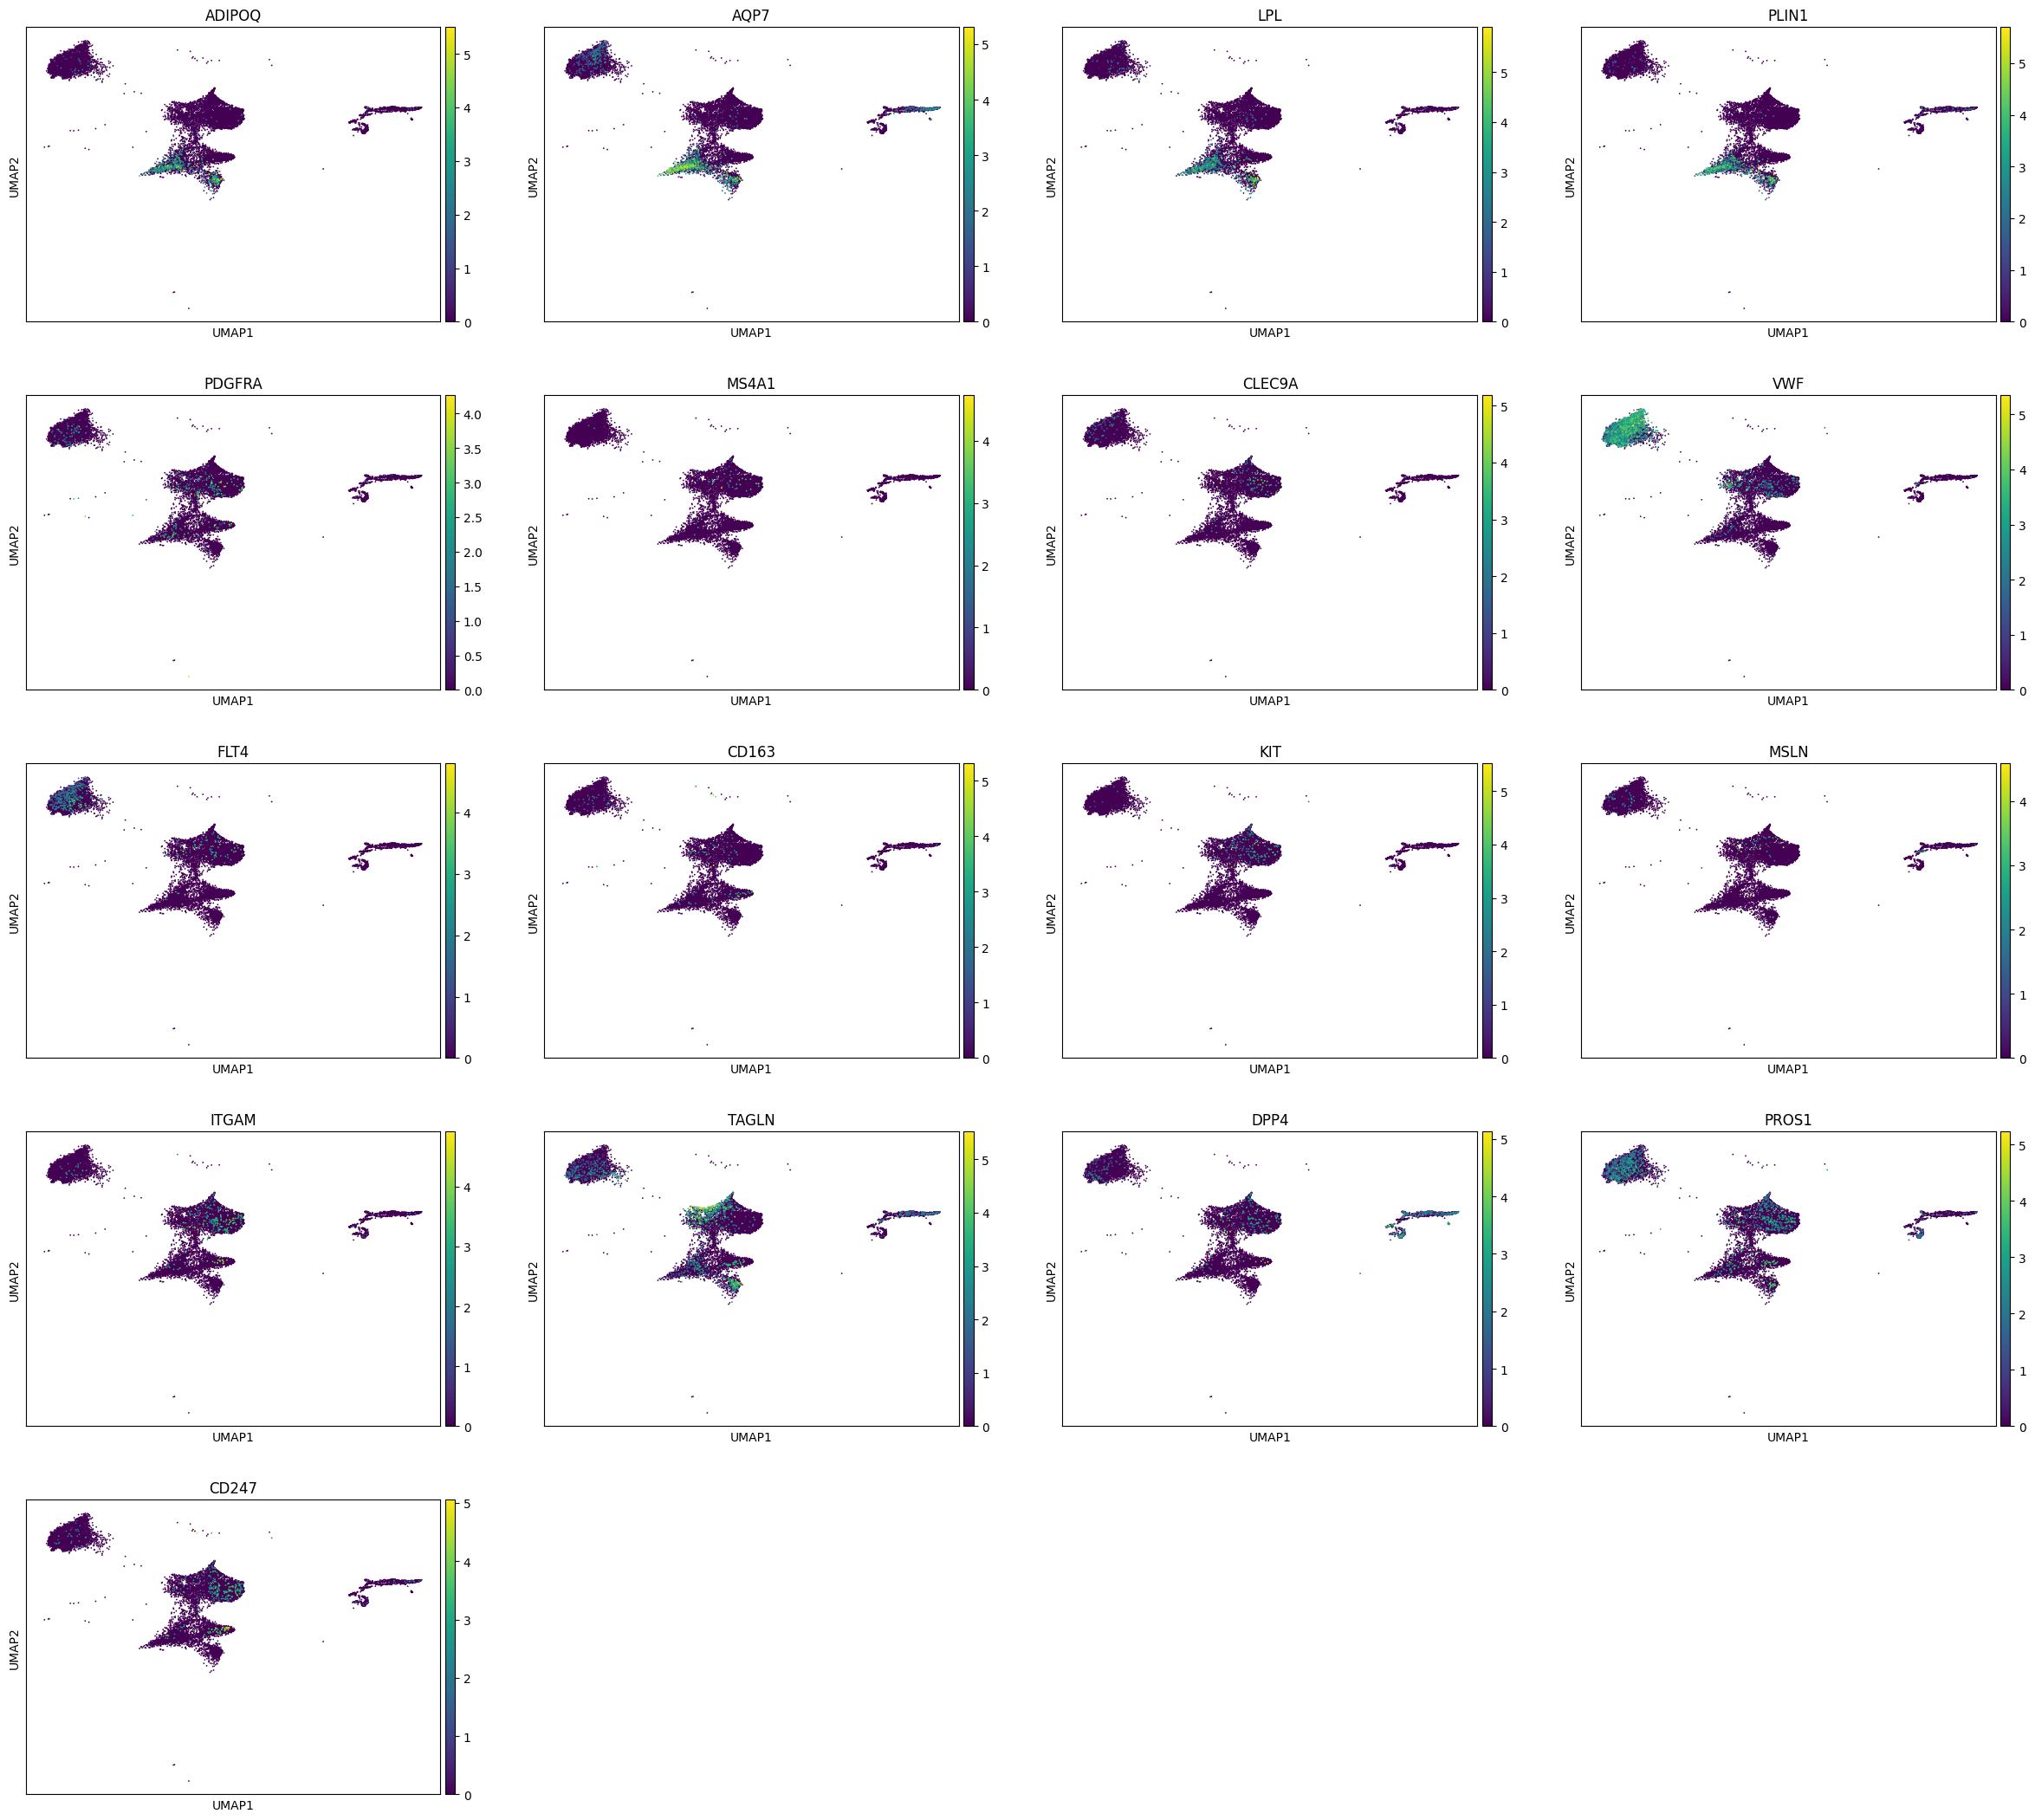

In [62]:
sc.pl.umap(allsample_rna[allsample_rna.obs['leiden_scVI'].isin(['7', '8', '10', '14'])], color=celltype_markers, layer='log_10k_norm',)

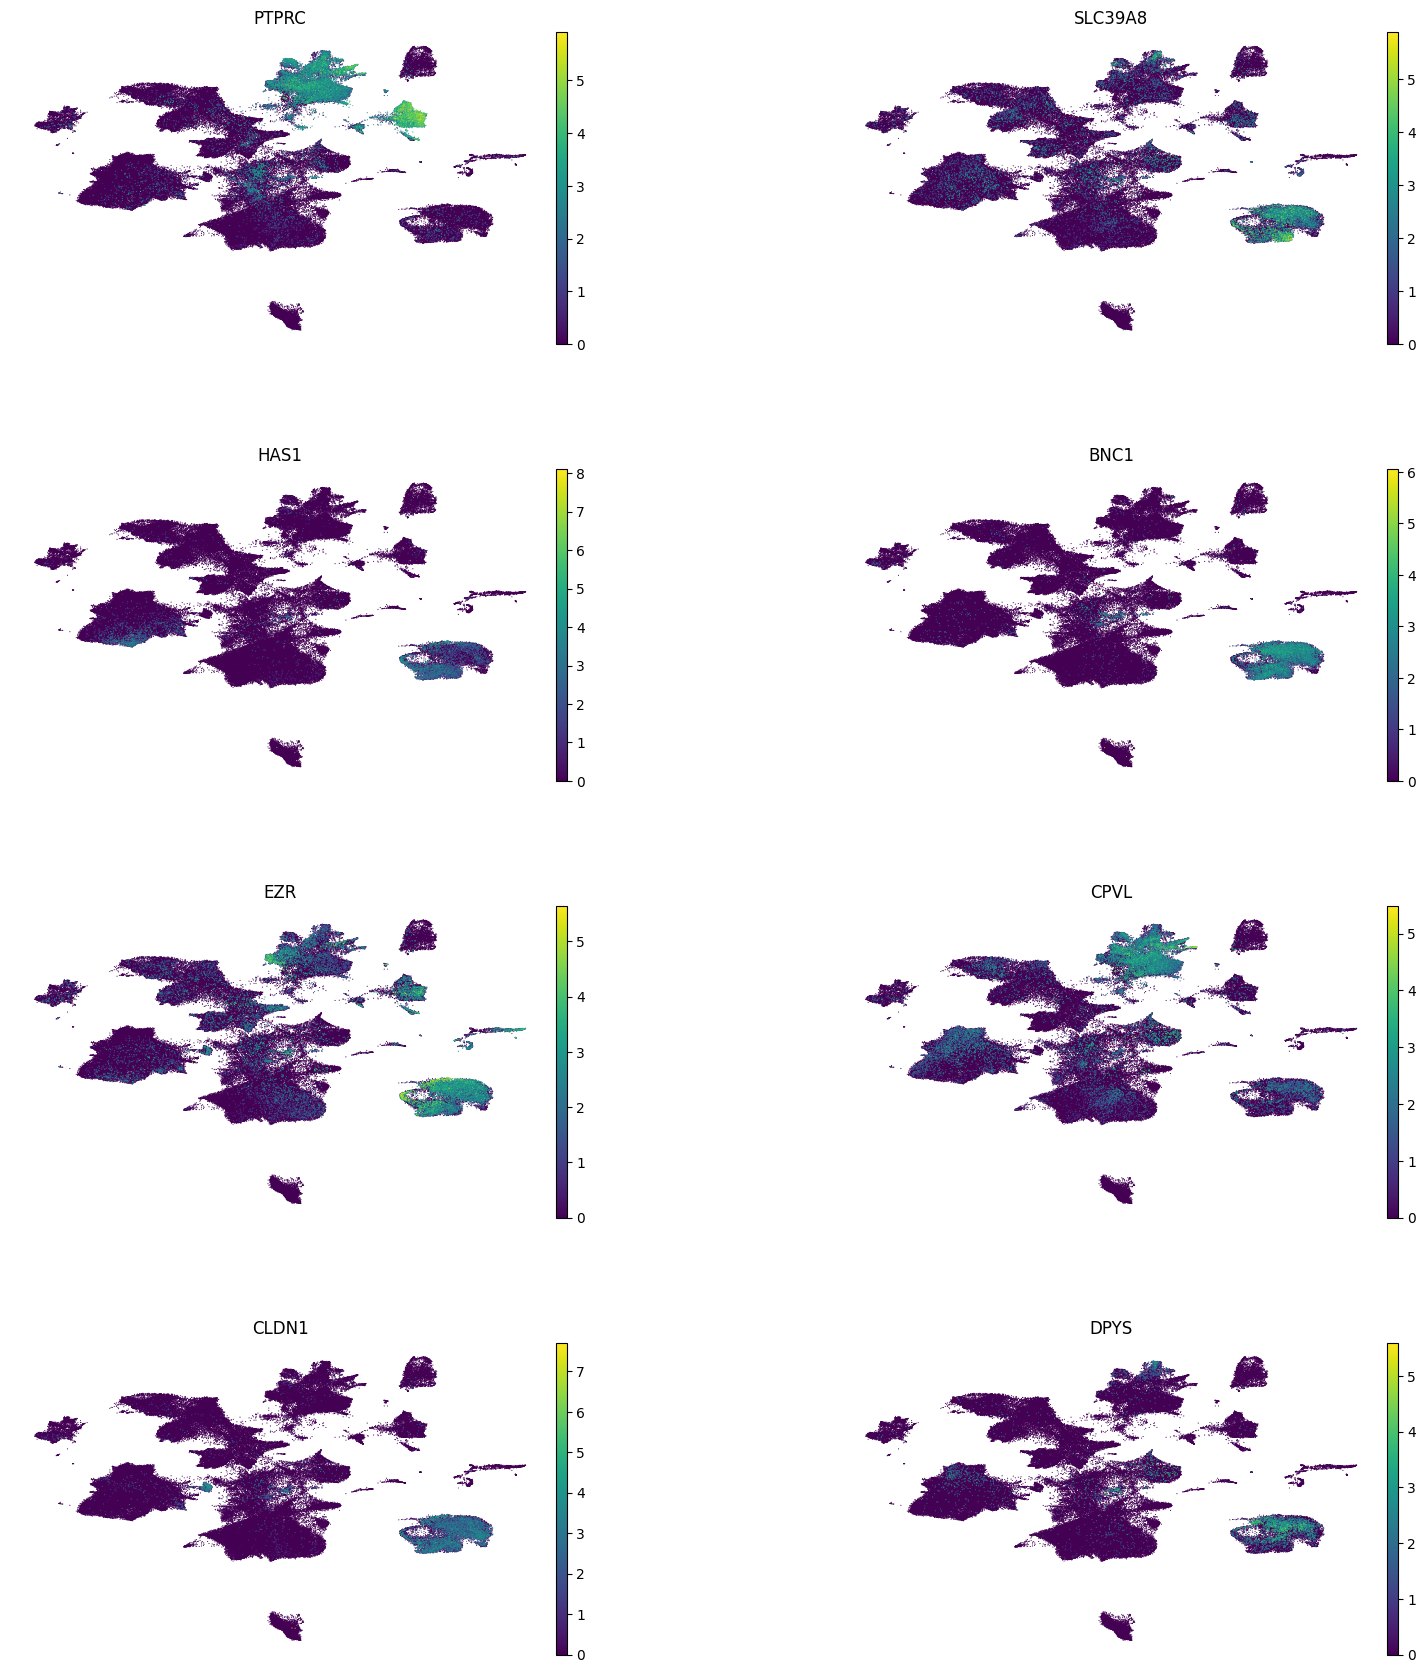

In [57]:
sc.pl.umap(allsample_rna, color=ab_celltype_markers[ab_celltype_markers[0] == 'Neutrophil'][1].values[0].split(','), frameon=False, ncols=2, layer='log_10k_norm',
           wspace=0.4, hspace=0.4, size=2.5)

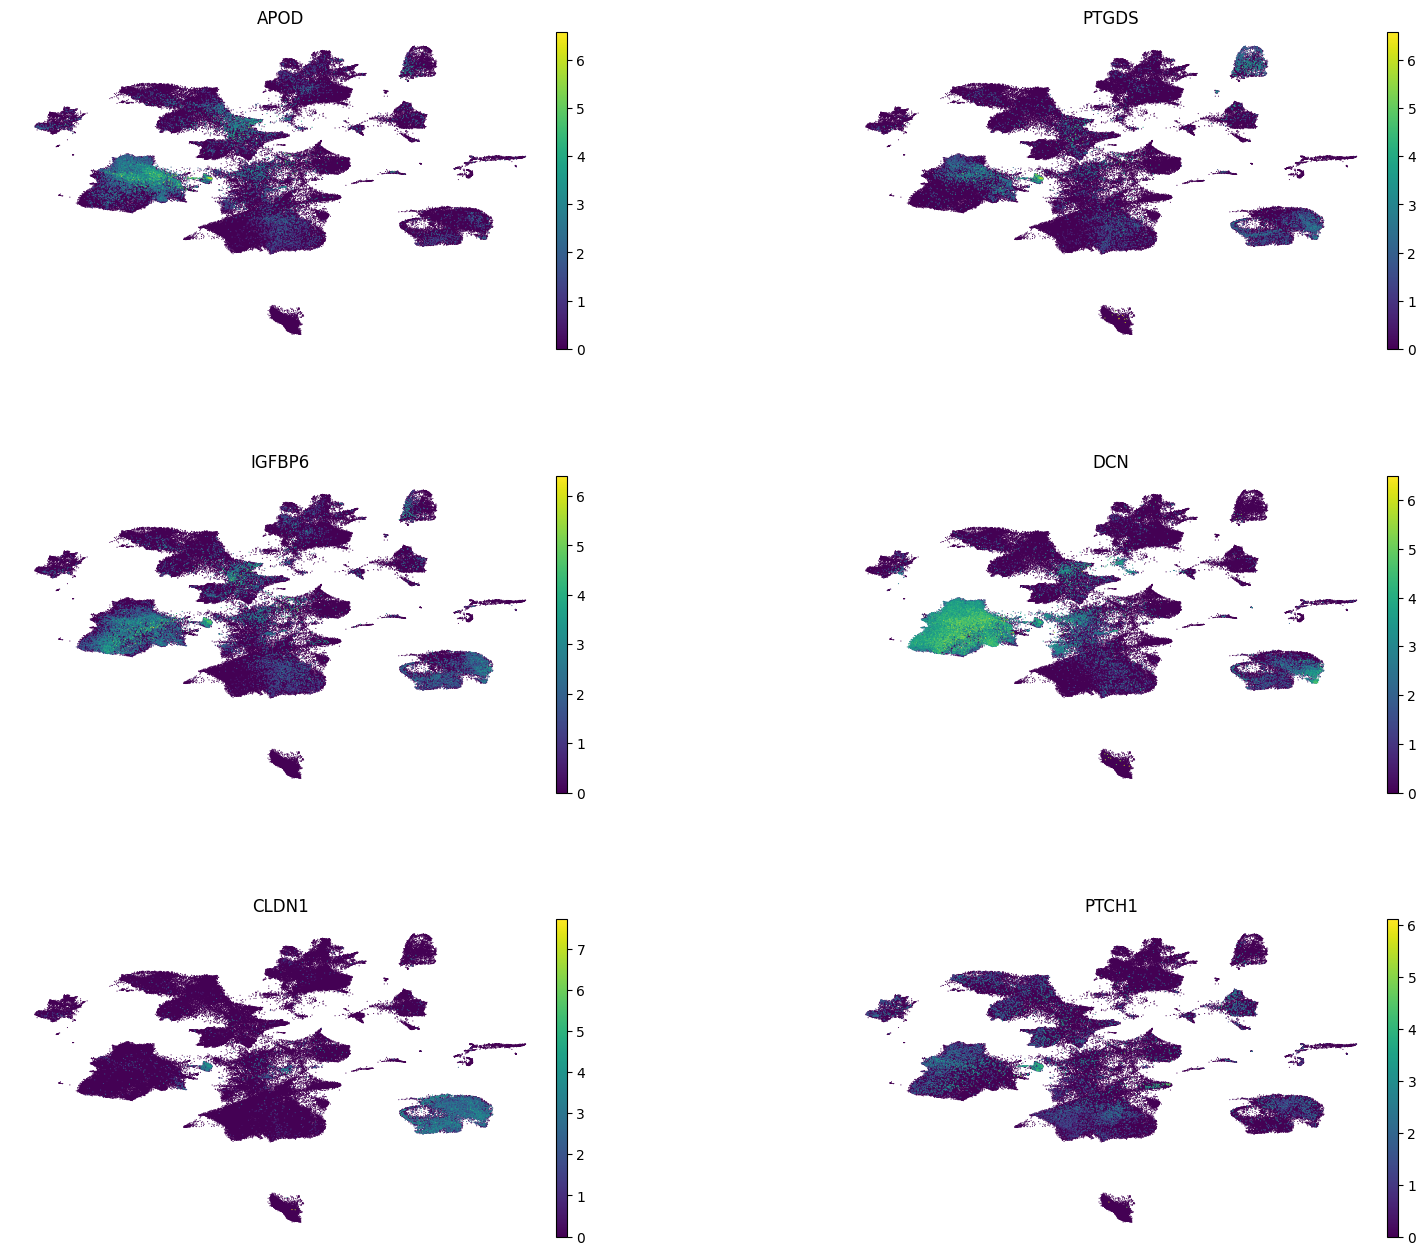

In [56]:
sc.pl.umap(allsample_rna, color=nk_celltype_markers[nk_celltype_markers[0] == 'Mesen'][1].values[0].split(','), frameon=False, ncols=2, layer='log_10k_norm', 
           wspace=0.4, hspace=0.4, size=2.5)

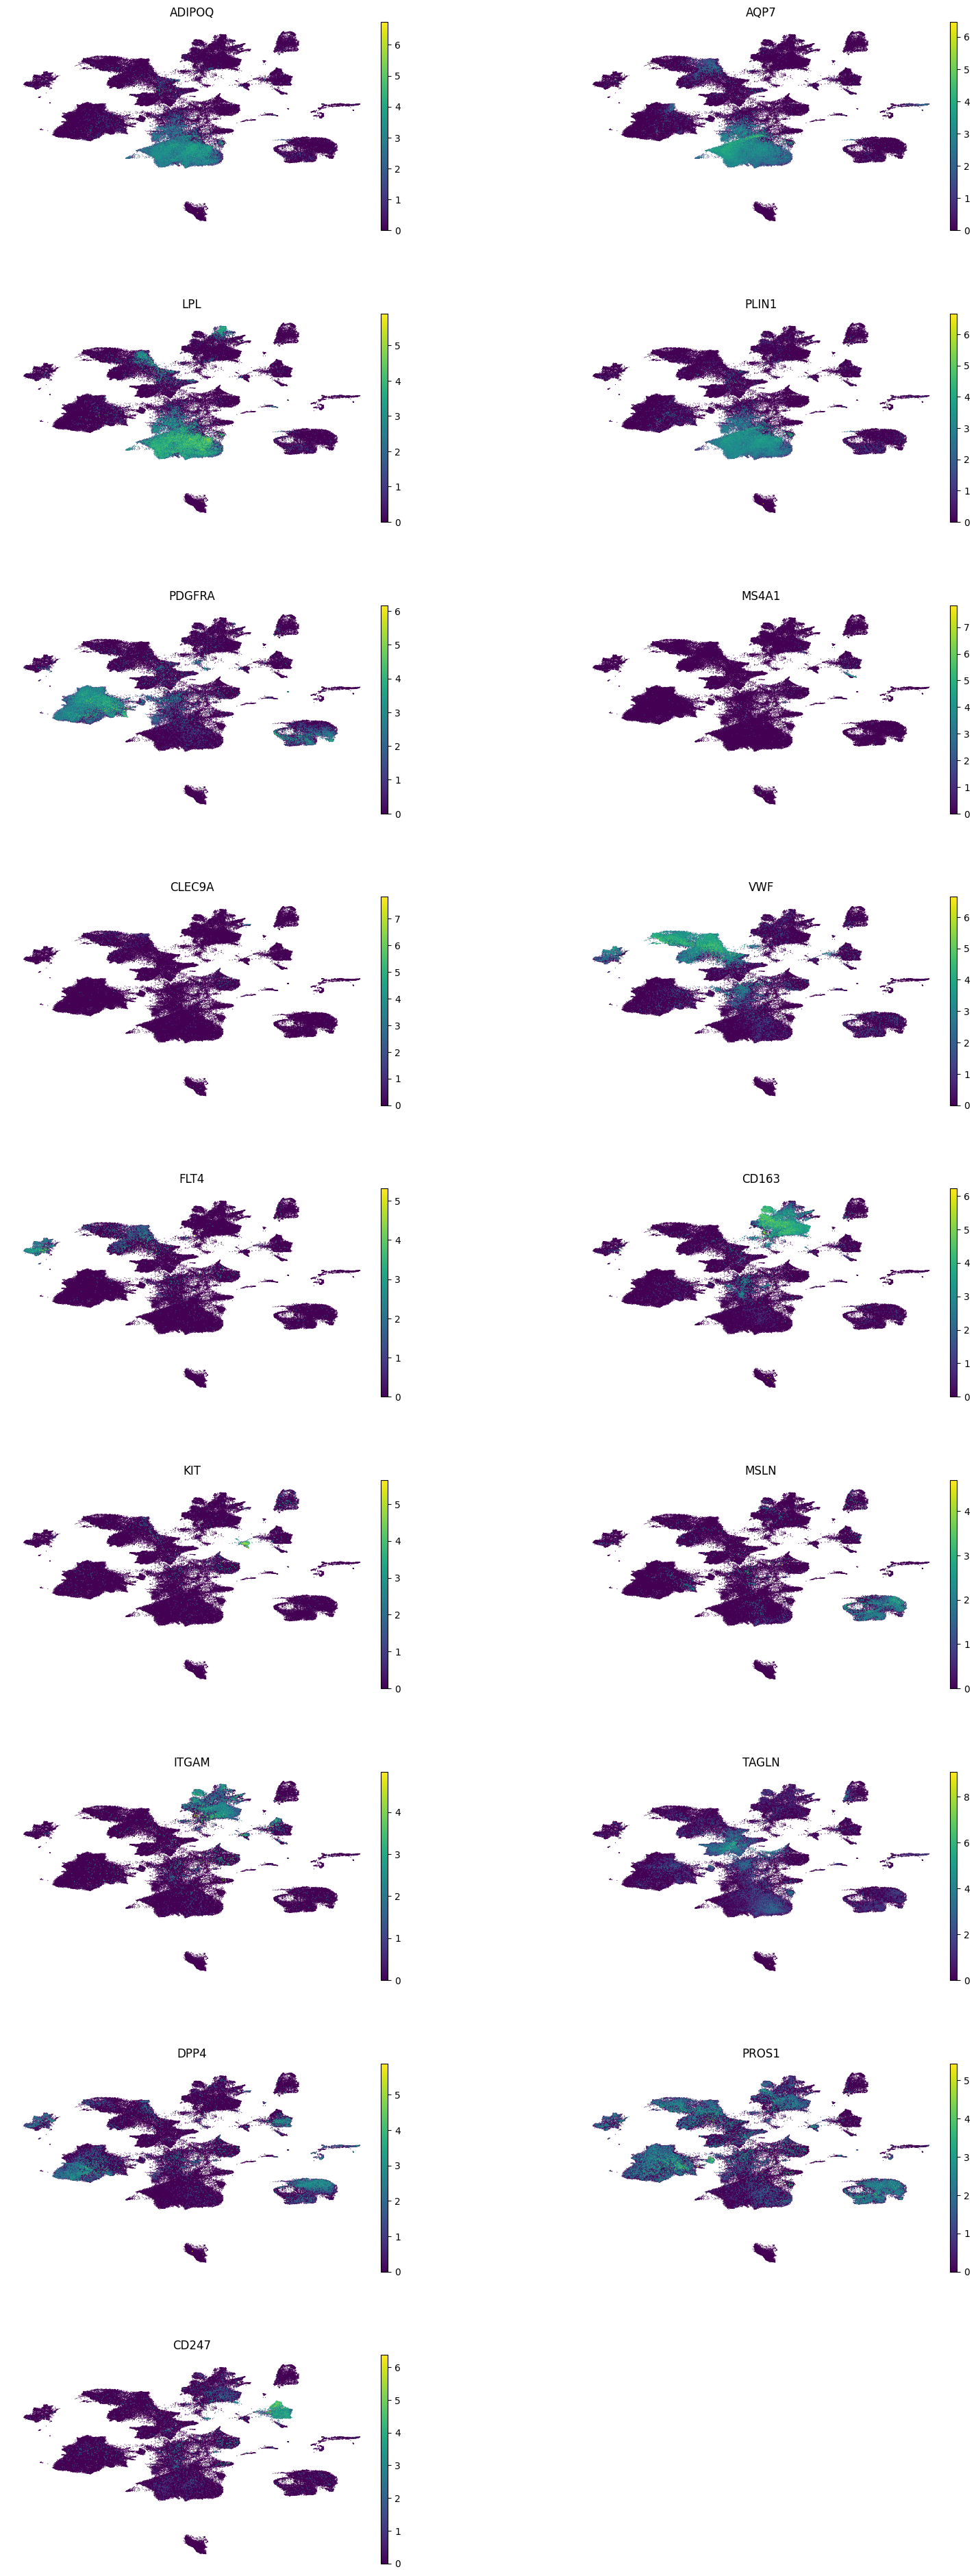

In [9]:
sc.pl.umap(allsample_rna, color=celltype_markers, layer='log_10k_norm', 
           frameon=False, ncols=2, wspace=0.4, hspace=0.4, size=2.5)

In [65]:
## with above umaps I constructed the celltype assignment table --> 
## load it
shiyi_celltype_file = '/home/syyang/GitRepo/atac/Analysis_adipose/allsamples_rna/allsample_rna_annotation_shiyi.tsv'
shiyi_celltype_rna = pd.read_csv(shiyi_celltype_file, sep='\t')

In [76]:
shiyi_celltype_rna['cluster_str'] = shiyi_celltype_rna['cluster'].astype(str)

In [77]:
allsample_rna.obs['leiden_scVI_str'] = allsample_rna.obs['leiden_scVI'].astype(str)
allsample_rna.obs.head()

,sample,_scvi_batch,_scvi_labels,leiden_scVI,_scvi_raw_norm_scaling,cluster,leiden_scVI_str
GTGCAGCCATTACTCT-1,AB_AOM,0,0,0,0.188698,0,0
CCCTTAGTCAGCTCTC-1,AB_AOM,0,0,5,0.208297,5,5
CCTTTGGCACTAGGCC-1,AB_AOM,0,0,0,0.251779,0,0
TATACCTCACGTCTCT-1,AB_AOM,0,0,0,0.300117,0,0
TGCGACGCATGACTCA-1,AB_AOM,0,0,4,0.305950,4,4


In [84]:
allsample_rna.obs.reset_index(inplace=True, drop=False)
allsample_rna.obs = allsample_rna.obs.merge(shiyi_celltype_rna[['cluster_str', 'celltype']], left_on='leiden_scVI', right_on='cluster_str', how='left')

In [86]:
allsample_rna.obs.set_index('index', inplace=True, drop=True)

In [87]:
allsample_rna.obs.head()

,sample,_scvi_batch,_scvi_labels,leiden_scVI,_scvi_raw_norm_scaling,cluster_str,celltype
index,,,,,,,
GTGCAGCCATTACTCT-1,AB_AOM,0,0,0,0.188698,0,Adipocytes
CCCTTAGTCAGCTCTC-1,AB_AOM,0,0,5,0.208297,NaN,NaN
CCTTTGGCACTAGGCC-1,AB_AOM,0,0,0,0.251779,0,Adipocytes
TATACCTCACGTCTCT-1,AB_AOM,0,0,0,0.300117,0,Adipocytes
TGCGACGCATGACTCA-1,AB_AOM,0,0,4,0.305950,4,Mesothelial


In [98]:
save_df = allsample_rna.obs[['leiden_scVI', 'celltype', 'sample']].copy()
save_df.columns = ['leiden_scVI', 'cell_type', 'sample']
save_df.to_csv('/home/syyang/GitRepo/atac/Analysis_adipose/allsamples_rna/allsample_rna_celltype_asign_shiyi.tsv', index=True, header=True, sep='\t',  na_rep='NA')